# Document Segmentation with SAT (Segment Any Text)

**Author**: Konrad Jelen (kj)<br>
**Pipeline stage**: 1 - statement-level document segmentation

This notebook splits a source document into atomic statements using the **SaT `sat-3l-sm`** model - a 3-layer subword XLM-R sentence segmenter from *Segment Any Text* - running PyTorch inference on **GPU** rather than the OpenVINO INT8 build. Statement-level segmentation is the first stage of the document-distance pipeline: downstream stages embed each statement and compare two documents with optimal transport, so the granularity of this split bounds the quality of every later measure.

## Approach
1. **Extract** raw text from the source PDF with `pdfplumber` - the corpus arrives as PDF and SaT operates on plain text
2. **Load** the `sat-3l-sm` segmenter onto the GPU in half precision - GPU inference is the requested path and fp16 halves memory with no quality loss for this small model
3. **Segment** the full document into sentence-level statements - optimal-transport document distance matches statements across documents regardless of position, so sentences are the natural transport unit
4. **Persist** the statements as a parquet table in `data/interim/` - a stable, typed artifact the embedding stage consumes without re-running the model

## Outputs
- `data/interim/01-statements.parquet` - one row per statement with id, text, and char/word length
- In-notebook summary: statement count, length statistics, and a length-distribution histogram

## GPU Selection

Selects the **RTX 5000 Ada** (nvidia-smi index 2, compute 8.9, 32 GB) - a well-supported Ada-generation card preferred here over the Blackwell RTX 5090 to avoid new-architecture kernel risk for this tiny model. `CUDA_DEVICE_ORDER=PCI_BUS_ID` forces torch's device order to match nvidia-smi (they differ on this host), and the env vars are set BEFORE any torch import so the isolation takes effect.

In [1]:
import os

# Make torch's device ordering match nvidia-smi (they differ on this host)
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# Select RTX 5000 Ada (nvidia-smi index 2) - MUST be set before importing torch
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
import subprocess as _sp
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu
# Avoid tokenizers fork-parallelism warnings/deadlocks
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Imports

All imports for the notebook, grouped by purpose. `autoreload` keeps any edits to `src/docdistance_estimator` live without a kernel restart.

In [2]:
%load_ext autoreload
%autoreload 2

# Standard library
import random
from pathlib import Path

# Data processing
import numpy as np
import polars as pl

# PDF extraction
import pdfplumber

# Deep learning
import torch

# Sentence segmentation
from wtpsplit import SaT

# Rich console output
from rich import print as rprint
from rich.console import Console
from rich.table import Table

console = Console()

## Reproducibility

SaT inference is deterministic, but the global seeds are pinned so any sampling, batching, or augmentation added later stays reproducible.

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Configuration

Segmentation hyperparameters and paths. `THRESHOLD` controls boundary sensitivity - lower values cut more aggressively into shorter statements; `None` uses the model default tuned on the VitaminC set. The Device block confirms `CUDA_VISIBLE_DEVICES` resolved to the intended GPU.

In [4]:
# Model
MODEL_NAME = "sat-3l-sm"   # 3-layer subword XLM-R sentence segmenter (Segment Any Text)
USE_HALF = True            # fp16 inference - halves memory, no quality loss for this model
THRESHOLD = None           # boundary probability cutoff; None = model default
BLOCK_SIZE = 512           # tokens per inference block
BATCH_SIZE = 32            # blocks per forward pass

# Paths
PROJ_ROOT = Path.cwd().parent
PDF_PATH = (
    PROJ_ROOT / "data" / "external"
    / "ibm-enterprise-ai-adoption.pdf"
)
OUTPUT_PATH = PROJ_ROOT / "data" / "interim" / "01-statements.parquet"

# Device - resolved at runtime; GPU info shown in render below
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"
gpu_compute_cap = (
    f"{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}"
    if torch.cuda.is_available() else "N/A"
)
gpu_memory_gb = (
    torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
)

rprint(f"""[bold medium_purple]Configuration[/bold medium_purple]
[dim]{"─" * 44}[/dim]
[bold slate_blue1]Model[/bold slate_blue1]
  Name: [cadet_blue]{MODEL_NAME}[/cadet_blue]
  Half precision: [grey70]{USE_HALF}[/grey70]
  Threshold: [grey70]{THRESHOLD}[/grey70]
  Block size: [dark_sea_green]{BLOCK_SIZE}[/dark_sea_green]
  Batch size: [dark_sea_green]{BATCH_SIZE}[/dark_sea_green]

[bold slate_blue1]Paths[/bold slate_blue1]
  Source PDF: [dim]{PDF_PATH.name}[/dim]
  Output: [dim]{OUTPUT_PATH}[/dim]

[bold slate_blue1]Device[/bold slate_blue1]
  Using: [dark_sea_green]{device}[/dark_sea_green]
  GPU: [cadet_blue]{gpu_name}[/cadet_blue]
  Compute cap: [dark_sea_green]{gpu_compute_cap}[/dark_sea_green]
  Memory: [light_sea_green]{gpu_memory_gb:.1f} GB[/light_sea_green]
""")

Configuration
────────────────────────────────────────────
Model
  Name: sat-3l-sm
  Half precision: True
  Threshold: None
  Block size: 512
  Batch size: 32

Paths
  Source PDF: Data Suggests Growth in Enterprise Adoption of AI is Due to Widespread Deploymen.pdf
  Output: /home/lab/workspace/learning/projects/docdistance-estimator/data/interim/01-statements.parquet

Device
  Using: cuda
  GPU: NVIDIA RTX 5000 Ada Generation
  Compute cap: 8.9
  Memory: 34.4 GB

## Data Loading

Extracts plain text from the source PDF page by page with `pdfplumber` and concatenates it into one string. Pages with no extractable text (pure figures) yield empty strings and are skipped in the join.

In [5]:
with pdfplumber.open(PDF_PATH) as pdf:
    pages = [page.extract_text() or "" for page in pdf.pages]

raw_text = "\n".join(p for p in pages if p.strip())

rprint(
    f"[steel_blue]Loaded[/steel_blue] [dark_sea_green]{len(pages)}[/dark_sea_green] pages, "
    f"[dark_sea_green]{len(raw_text):,}[/dark_sea_green] characters"
)

Loaded 6 pages, 10,043 characters

## Segmenter

Loads the `sat-3l-sm` weights from the Hugging Face hub and moves them onto the selected GPU; half precision is applied before the device transfer. The first run downloads the model (a few MB); later runs hit the local cache.

In [6]:
sat = SaT(MODEL_NAME)
if torch.cuda.is_available():
    if USE_HALF:
        sat.half()
    sat.to(device)

rprint(
    f"[dark_sea_green]✓[/dark_sea_green] SaT [cadet_blue]{MODEL_NAME}[/cadet_blue] "
    f"ready on [dark_sea_green]{device}[/dark_sea_green]"
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/965 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/855M [00:00<?, ?B/s]

/home/lab/.local/lib/python3.13/site-packages/huggingface_hub/file_download.py:1856: DeprecationWarning: hf_xet.download_files() is deprecated. Use XetSession().new_file_download_group().start_download_file() instead.
  xet_get(


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

✓ SaT sat-3l-sm ready on cuda

## Segmentation

Runs the segmenter over the full document text, producing sentence-level statements; empty fragments are dropped. This is the core operation - every statement here becomes one transport "pile" in the downstream distance computation.

In [7]:
split_kwargs = {"block_size": BLOCK_SIZE, "batch_size": BATCH_SIZE}
if THRESHOLD is not None:
    split_kwargs["threshold"] = THRESHOLD

raw_statements = sat.split(raw_text, **split_kwargs)
statements = [s.strip() for s in raw_statements if s.strip()]

rprint(
    f"[steel_blue]Segmented into[/steel_blue] "
    f"[dark_sea_green]{len(statements)}[/dark_sea_green] statements"
)

Segmented into 163 statements

## Save

Persists the statements as a typed parquet table in `data/interim/` - one row per statement with character and word lengths, ready for the embedding stage to consume.

In [8]:
df = pl.DataFrame(
    {
        "statement_id": list(range(len(statements))),
        "text": statements,
        "n_chars": [len(s) for s in statements],
        "n_words": [len(s.split()) for s in statements],
    }
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.write_parquet(OUTPUT_PATH)

rprint(
    f"[dark_sea_green]✓[/dark_sea_green] Wrote "
    f"[dark_sea_green]{df.height}[/dark_sea_green] statements → [dim]{OUTPUT_PATH}[/dim]"
)

✓ Wrote 163 statements → 
/home/lab/workspace/learning/projects/docdistance-estimator/data/interim/01-statements.parquet

## Summary

Sanity-check the segmentation: statement count, length statistics, a preview of the first statements, and a length-distribution histogram. Very short statements (1-2 words) often signal headers or list fragments; very long ones may indicate a missed boundary.

In [9]:
stats = df.select(
    n_statements=pl.len(),
    chars_mean=pl.col("n_chars").mean(),
    chars_median=pl.col("n_chars").median(),
    chars_max=pl.col("n_chars").max(),
    words_mean=pl.col("n_words").mean(),
    words_max=pl.col("n_words").max(),
).row(0, named=True)

rprint(f"""[bold medium_purple]Segmentation summary[/bold medium_purple]
[dim]{"─" * 44}[/dim]
  Statements: [dark_sea_green]{stats['n_statements']}[/dark_sea_green]
  Chars  - mean [dark_sea_green]{stats['chars_mean']:.0f}[/dark_sea_green]  median [dark_sea_green]{stats['chars_median']:.0f}[/dark_sea_green]  max [dark_sea_green]{stats['chars_max']}[/dark_sea_green]
  Words  - mean [dark_sea_green]{stats['words_mean']:.1f}[/dark_sea_green]  max [dark_sea_green]{stats['words_max']}[/dark_sea_green]
""")

table = Table(title="First statements")
table.add_column("#", style="grey70", justify="right")
table.add_column("words", style="steel_blue", justify="right")
table.add_column("statement", style="dark_sea_green")
for row in df.head(8).iter_rows(named=True):
    text = row["text"] if len(row["text"]) <= 100 else row["text"][:97] + "..."
    table.add_row(str(row["statement_id"]), str(row["n_words"]), text)
console.print(table)

Segmentation summary
────────────────────────────────────────────
  Statements: 163
  Chars  - mean 61  median 72  max 127
  Words  - mean 8.7  max 17

                                          First statements                                          
┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ # ┃ words ┃ statement                                                                            ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │     2 │ IBM Newsroom                                                                         │
│ 1 │     5 │ Data Suggests Growth in Enterprise                                                   │
│ 2 │     7 │ Adoption of AI is Due to Widespread                                                  │
│ 3 │     6 │ Deployment by Early Adopters, But Barriers                                           │
│ 4 │     5 │ Keep 40% in the Exploration                                                          │
│ 5 │     3 │ and Experimentation Phases                                                           │
│ 6 │    12 │ - About 42% of enterprise-scale companies surveyed (> 1,000 employees) report having │
│ 7 │     6 │ actively deployed AI in their business.                                              │
└───┴───────┴──────────────────────────────────────────────────────────────────────────────────────┘

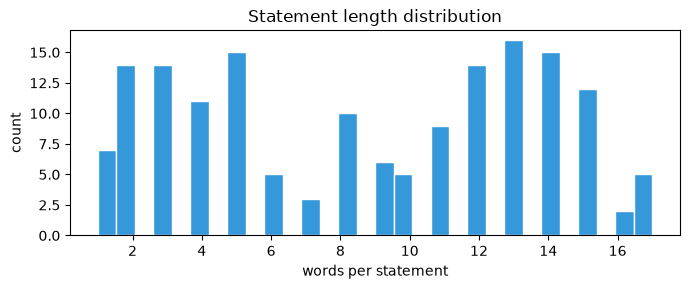

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(df["n_words"].to_list(), bins=30, color="#3498DB", edgecolor="white")
ax.set_xlabel("words per statement")
ax.set_ylabel("count")
ax.set_title("Statement length distribution")
plt.tight_layout()
plt.show()